# Leaf Instance Segmentation using maskRCNN (with a pre-trained model)

This interactive tutorial shows an example of using a pre-trained maskRCNN model to get leaf instances segmented from images. You will be able to download the pre-trained model from a provided link. You can also find the sample test data [here](https://github.com/danforthcenter/plantcv-tutorial_leaf_instance_segmentation/tree/master/test_img).


Made By Dannie Sheng Updated by Tess Rogers July 2025

In [1]:
import requests
url        = 'https://datasci.danforthcenter.org/mask_rcnn_leaves_0060.h5'
name_model = 'model.h5'
open('./{}'.format(name_model), 'wb').write(requests.get(url).content)


179179456

At this point you will find a file called "model.h5" in the current folder. 

Now you can follow the steps in this notebook for step-by-step implementation of leaf instance segmentation.

In [2]:
# import packages 
import os
import inferencing_utilities as funcs

/home/hsheng/miniconda3/envs/mrcnn/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/hsheng/miniconda3/envs/mrcnn/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/hsheng/miniconda3/envs/mrcnn/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/hsheng/miniconda3/envs/mrcnn/lib/python3

The following block is where you can custimize the code based on your own application needs:

Note on "suffix":
There are images for two seperate plants within the test_img folder. They are distinguished by the endinf suffix of "img11.jpg" or "img17.jpg". To ensure consisitency, check to make sure the suffix endings match between all the images. For this example, we will be analyzing images ending in "img17.jpg".


In [ ]:
## define the suffix of original image files. Make sure that all files have the same suffix format
suffix = 'crop-img17.jpg'

## set pattern for the date-time part in your data. Make sure that the date-time part in all filenames follow the same pattern
## each \d{#}-\ referecnes the timestamp for each image, the {#} will indicate the number of chacters, for example d{4} is 4 numbers for the year
## documentation on date-time patterns can be found here (https://docs.python.org/3.7/library/re.html)
pattern_datetime = '\d{4}-\d{2}-\d{2}-\d{2}-\d{2}'


In this section, you can indicate the folder of your own images for analysis, as well as determine the location of the resulting outputs. For the example tutorial, we will use the folder "test_img".

In [ ]:

## set the image folder for images to use for analysis 
imagedir = 'test_img'

## choose output directory for results
savedir = 'results_segmentation'
if not os.path.exists(savedir):
    os.makedirs(savedir)

## define class names. Since a pre-trained model is used here, and the model is trained with 2 classes: either "Background" or "Leaf", there are two classes defined.
class_names = ['BG', 'Leaf']

In [ ]:
## set directory for project files
rootdir = os.path.abspath("./")

## initialize the instance segmentation using the directories you set in the last code block
instance_seg =  funcs.instance_seg_inferencing(imagedir=imagedir, savedir=savedir, rootdir=rootdir, pattern_datetime=pattern_datetime, suffix=suffix, class_names=class_names, name_model=name_model)

## get configuration for instance segmentation
instance_seg.get_configure()

## load the pre-trained model
instance_seg.load_model()

## pre-defines colors for later visualization
instance_seg.define_colors()

## load the complete file list
instance_seg.get_file_list()

## optional code to print the list of files loaded
instance_seg.list_f

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
keep_dims is deprecated, use keepdims instead
Instructions for updating:
keep_dims is deprecated, use keepdims instead
Instructions for updating:
Use tf.cast instead.
Loading weights  /shares/mgehan_share/hsheng/plantcv-tutorial_leaf_instance_segmentation/model.h5
There are 12 images.


['10.9.1.241_pos-165-003-020_2019-10-22-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-10-23-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-10-24-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-10-25-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-10-26-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-10-27-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-10-28-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-10-29-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-10-30-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-10-31-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-11-01-11-05_crop-img17.jpg',
 '10.9.1.241_pos-165-003-020_2019-11-02-11-05_crop-img17.jpg']

For the next block, a single timepoint image  will be randomly selected to use as an example of what the image analysis output will look like. This will produce several images with segmented leaves.

Processing 1 images
image                    shape: (500, 499, 3)         min:    0.00000  max:  171.00000  uint8
molded_images            shape: (1, 1024, 1024, 3)    min: -123.70000  max:   52.20000  float64
image_metas              shape: (1, 14)               min:    0.00000  max: 1024.00000  float64
anchors                  shape: (1, 261888, 4)        min:   -0.08847  max:    1.02591  float32
There were 10 instances segmented in 10.9.1.241_pos-165-003-020_2019-10-31-11-05_crop-img17.jpg, 10 were left after quality control.



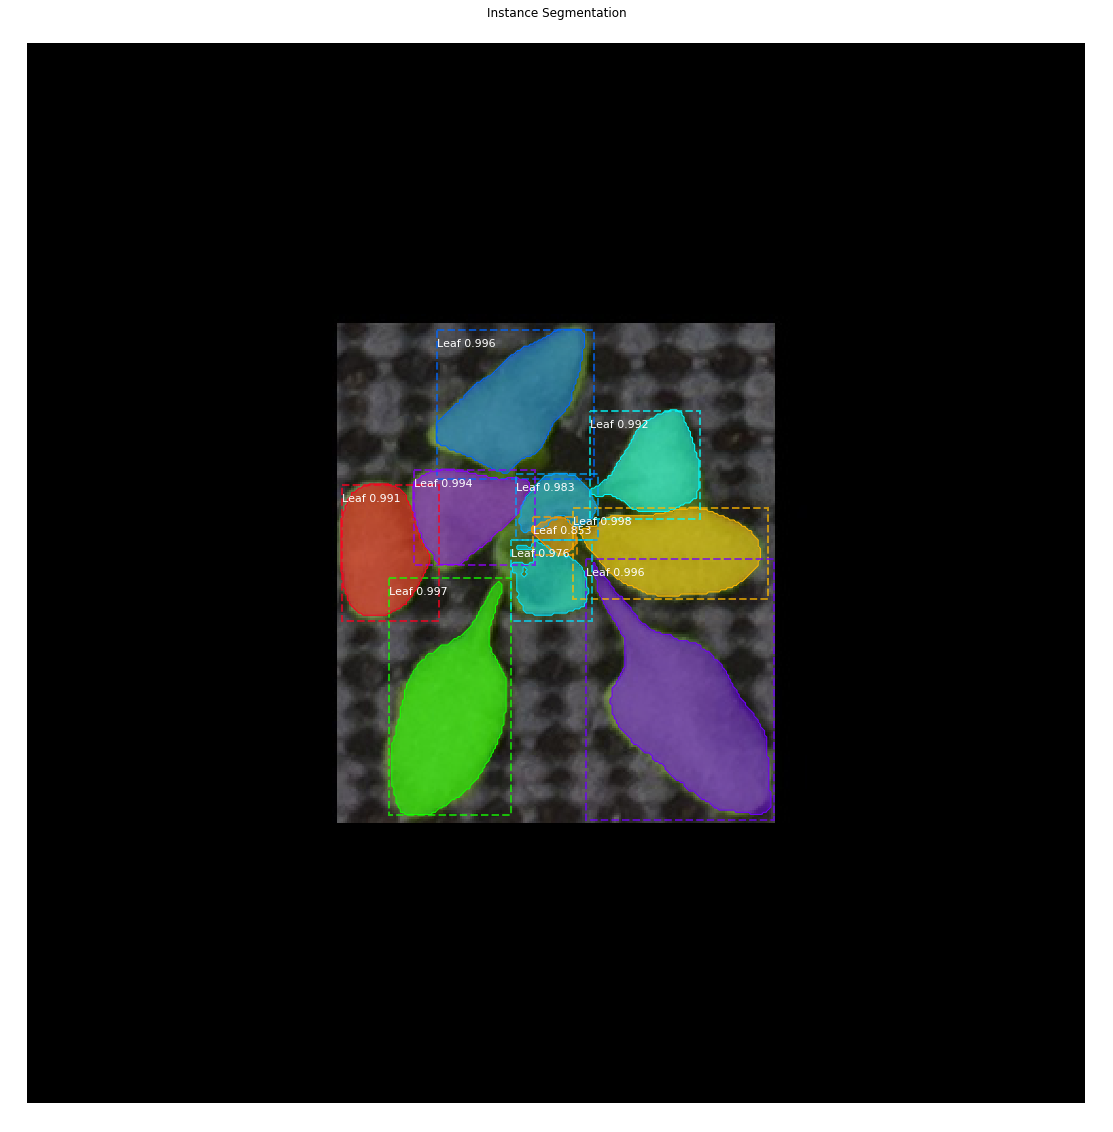

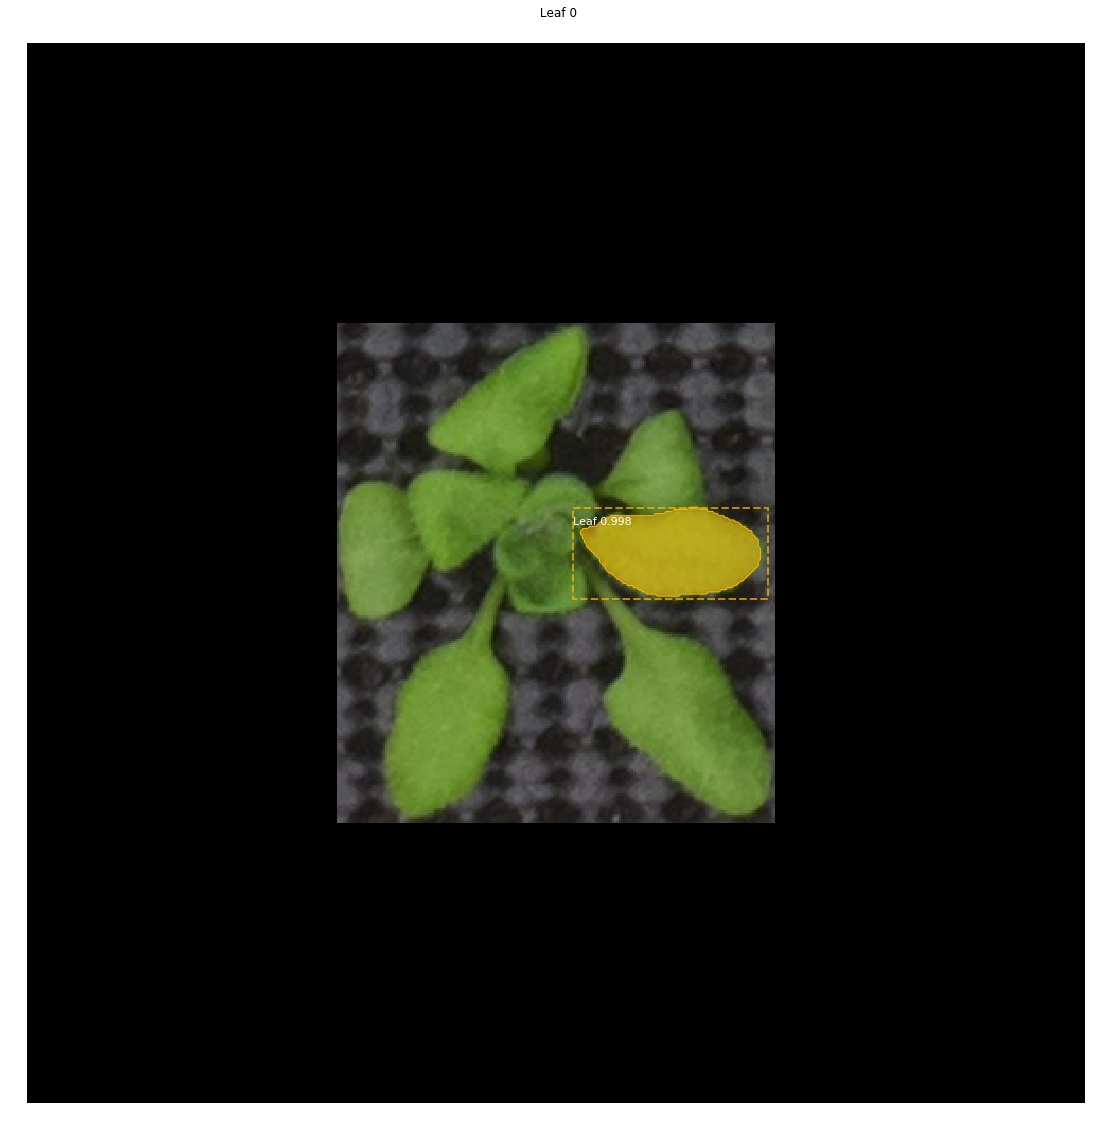

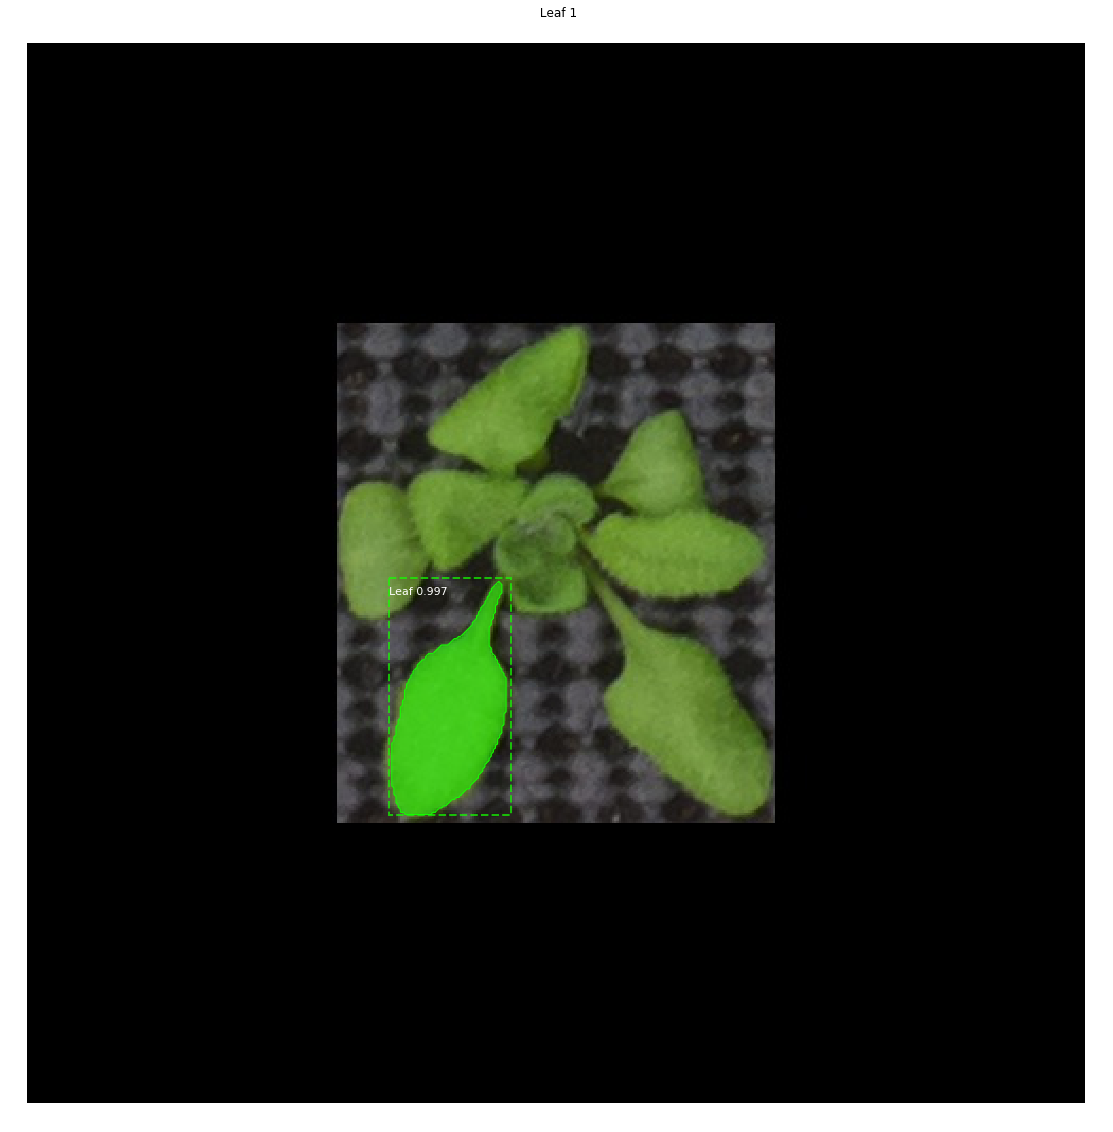

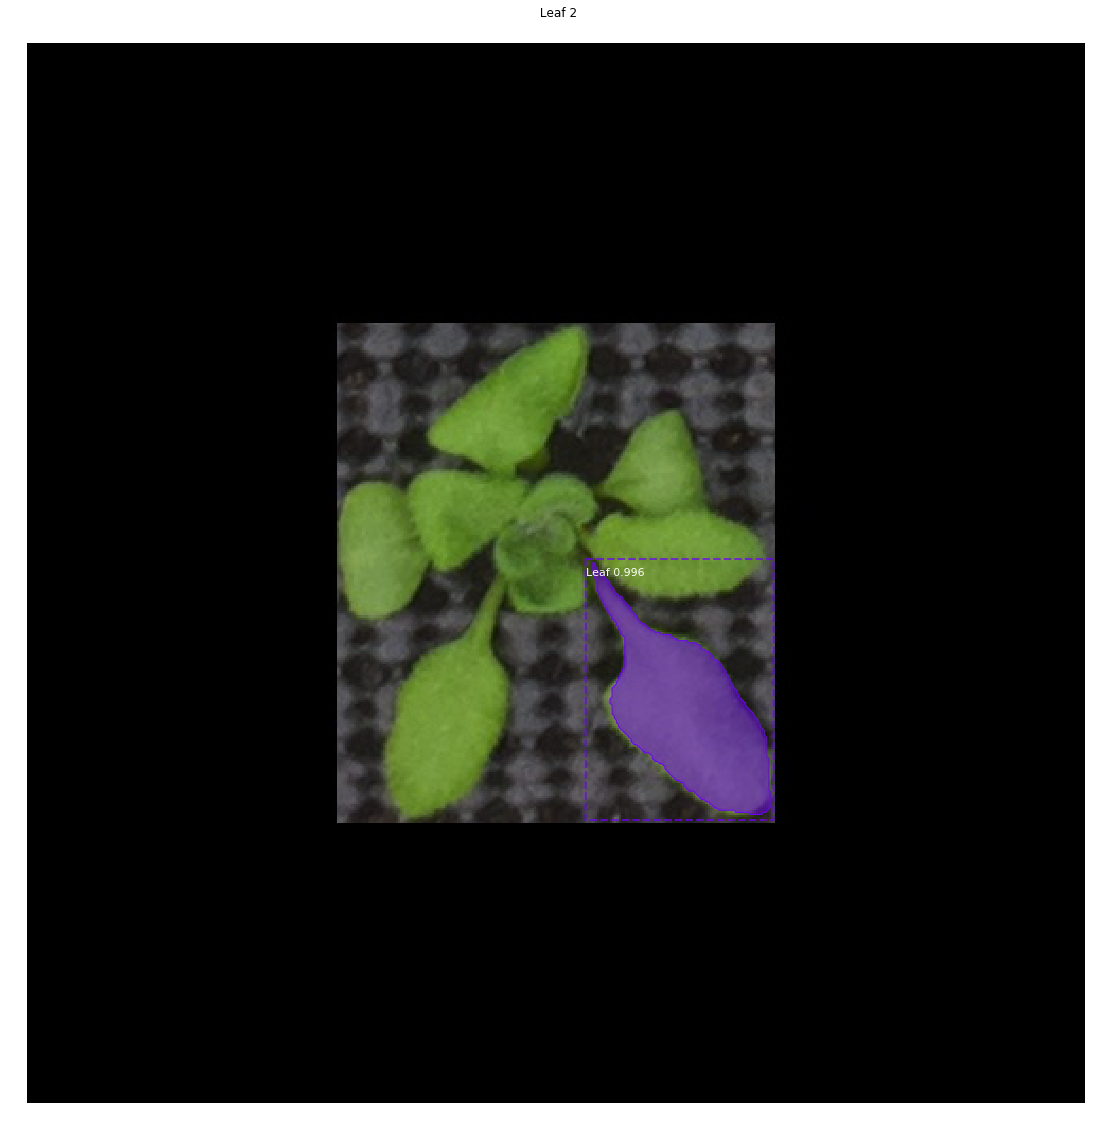

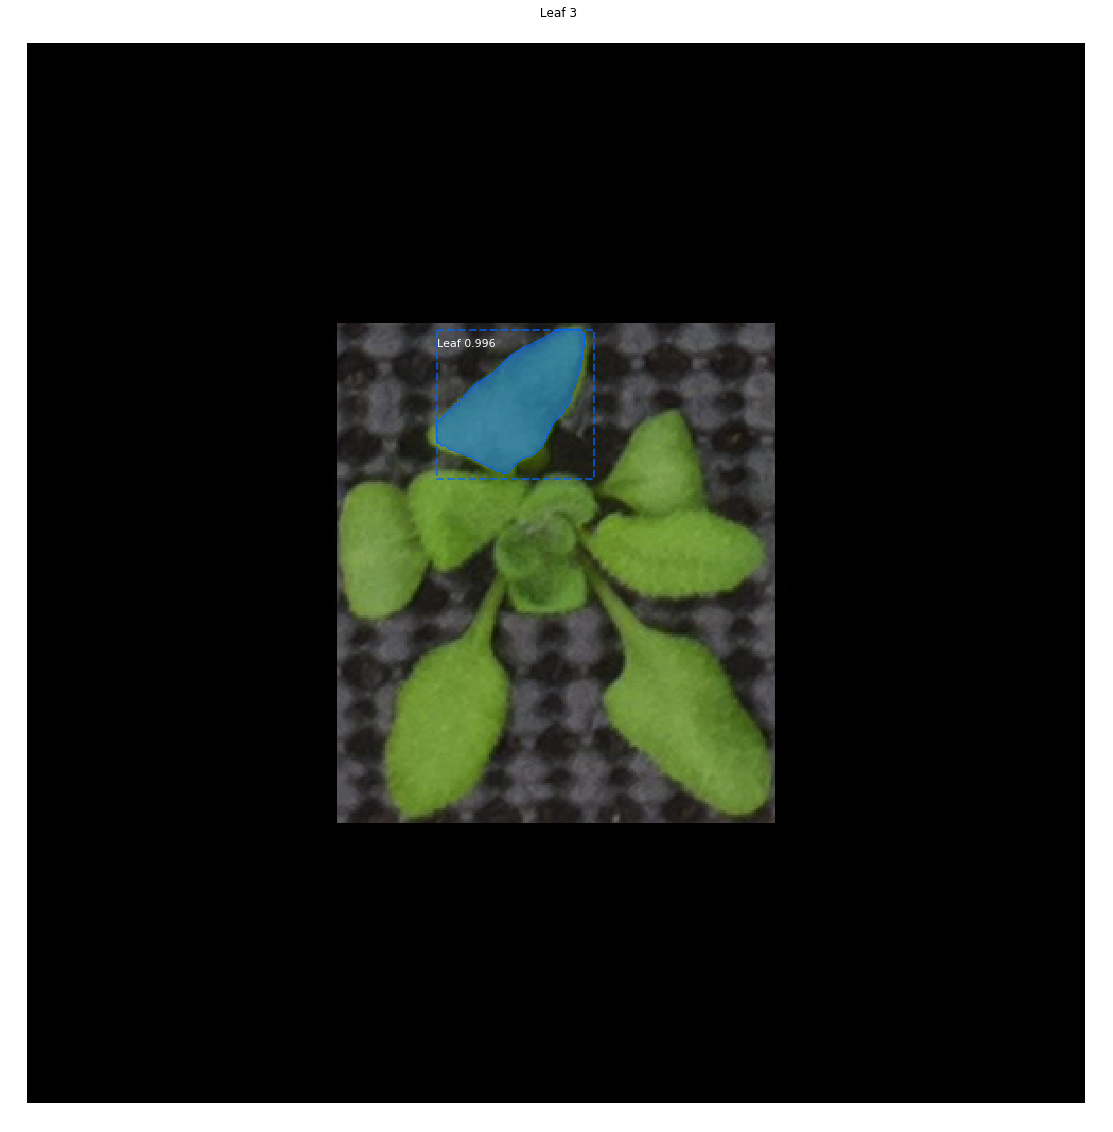

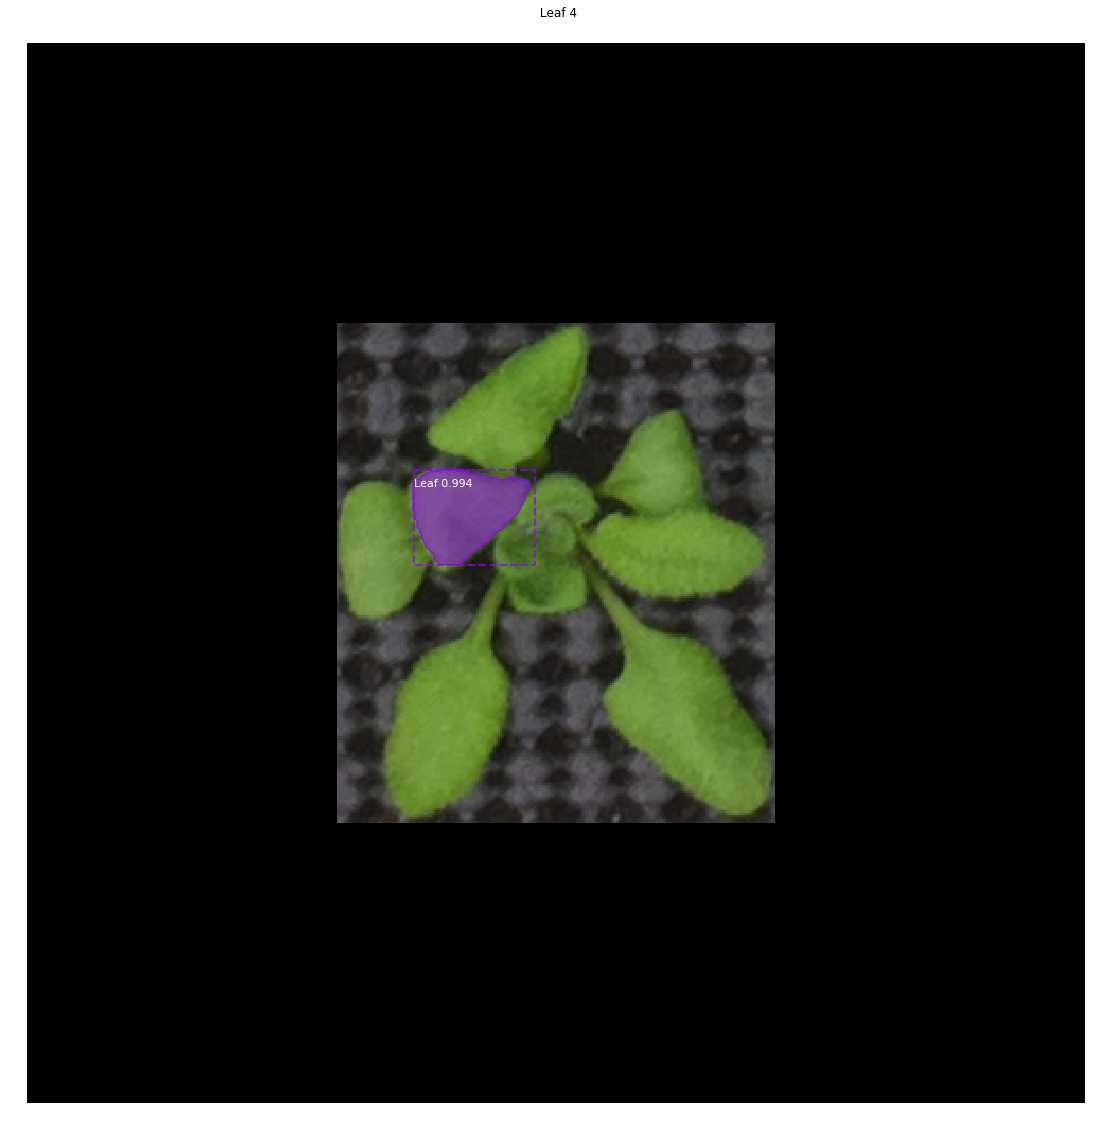

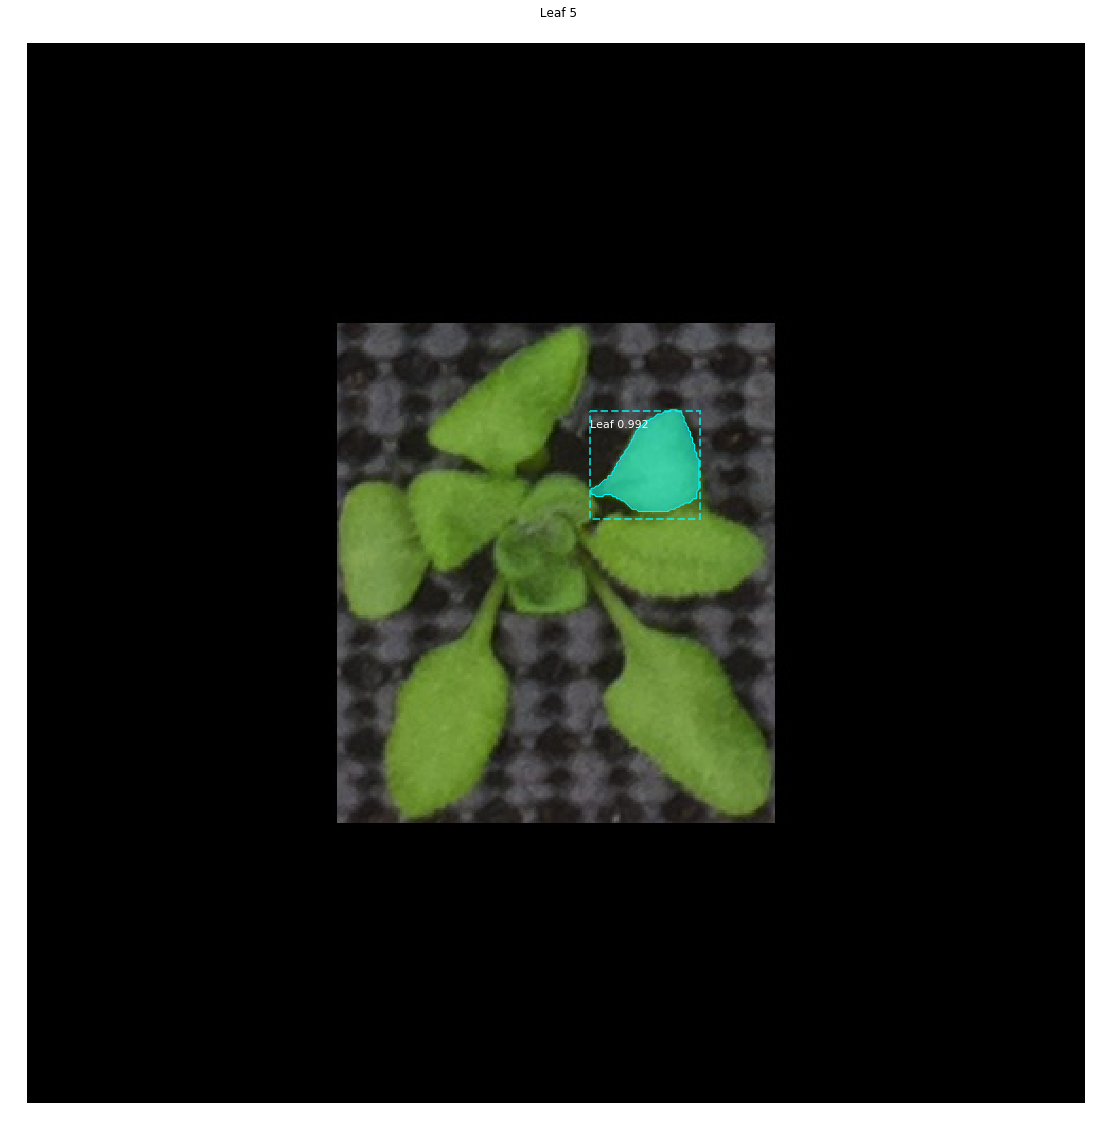

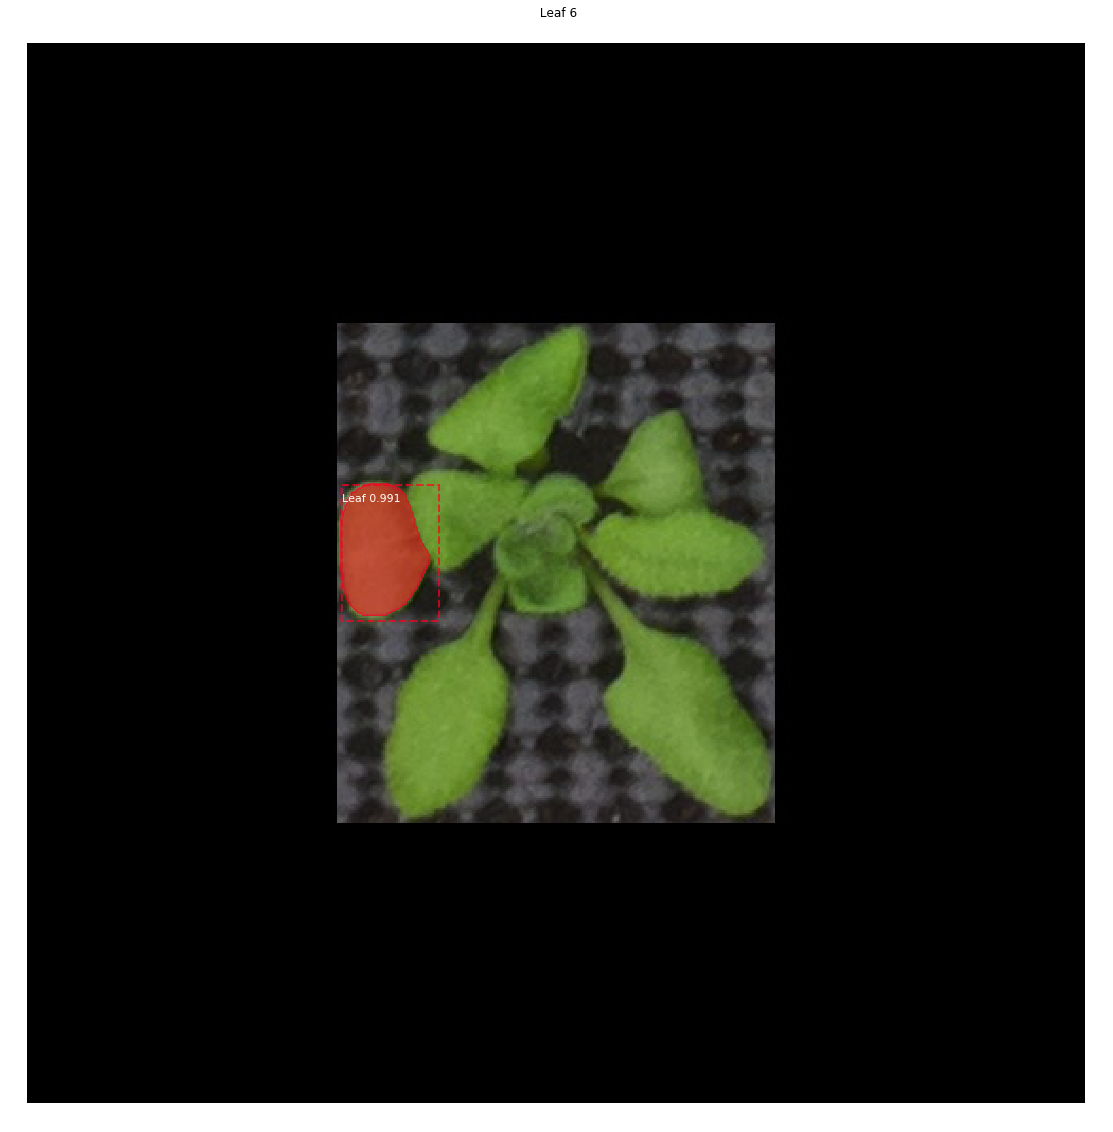

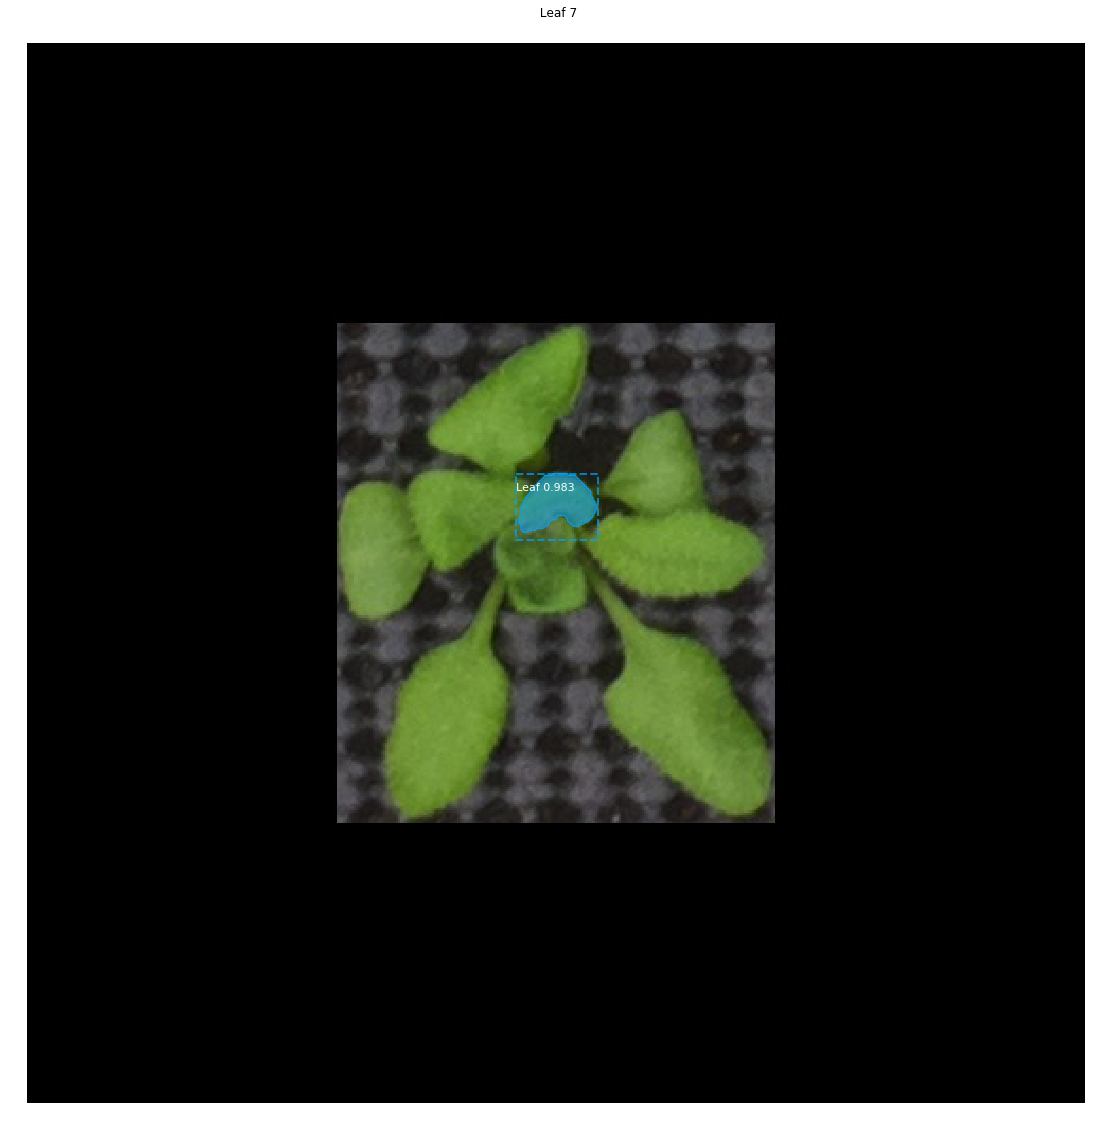

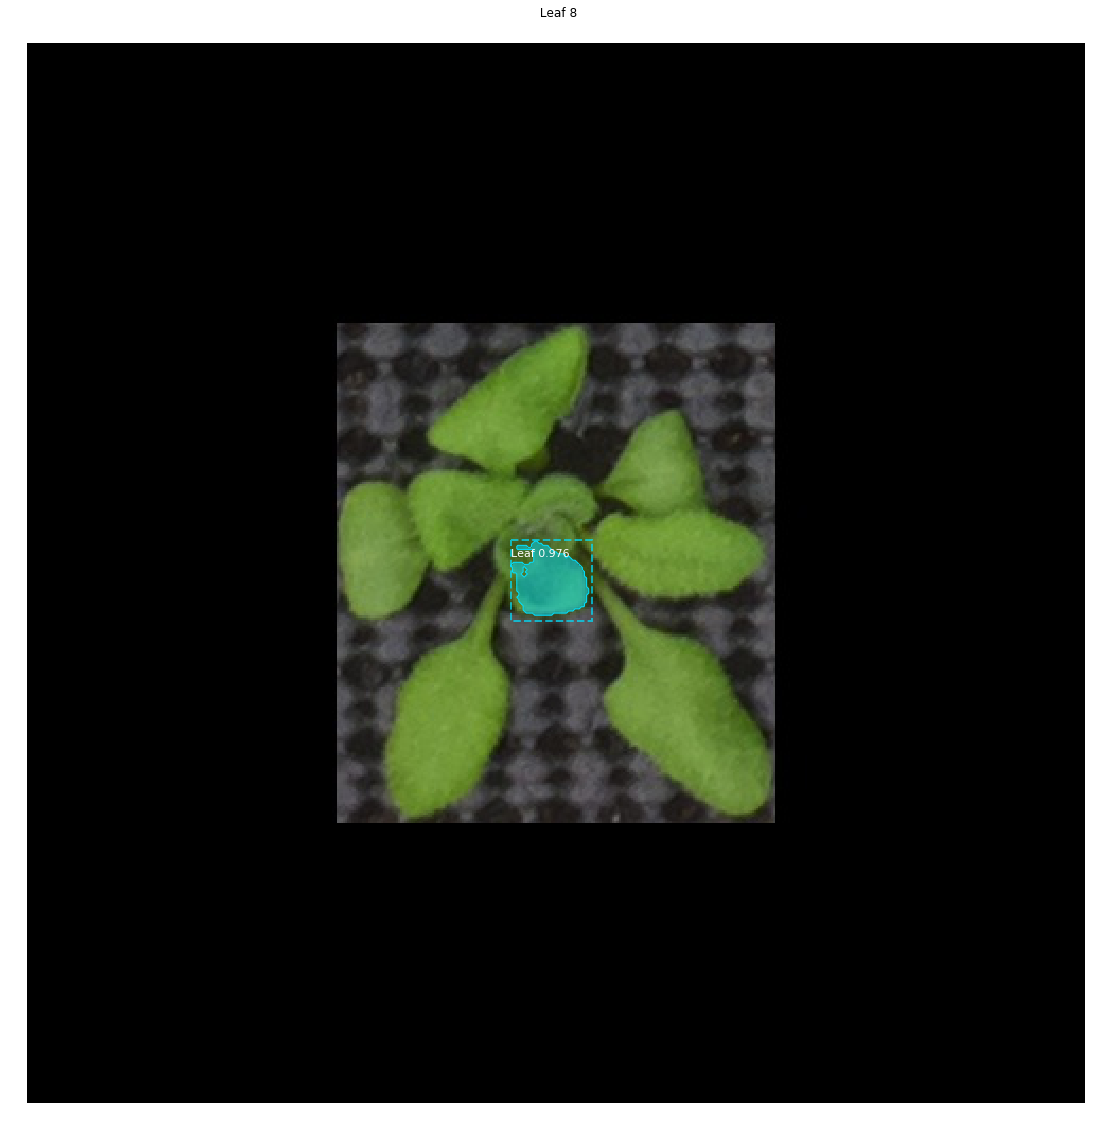

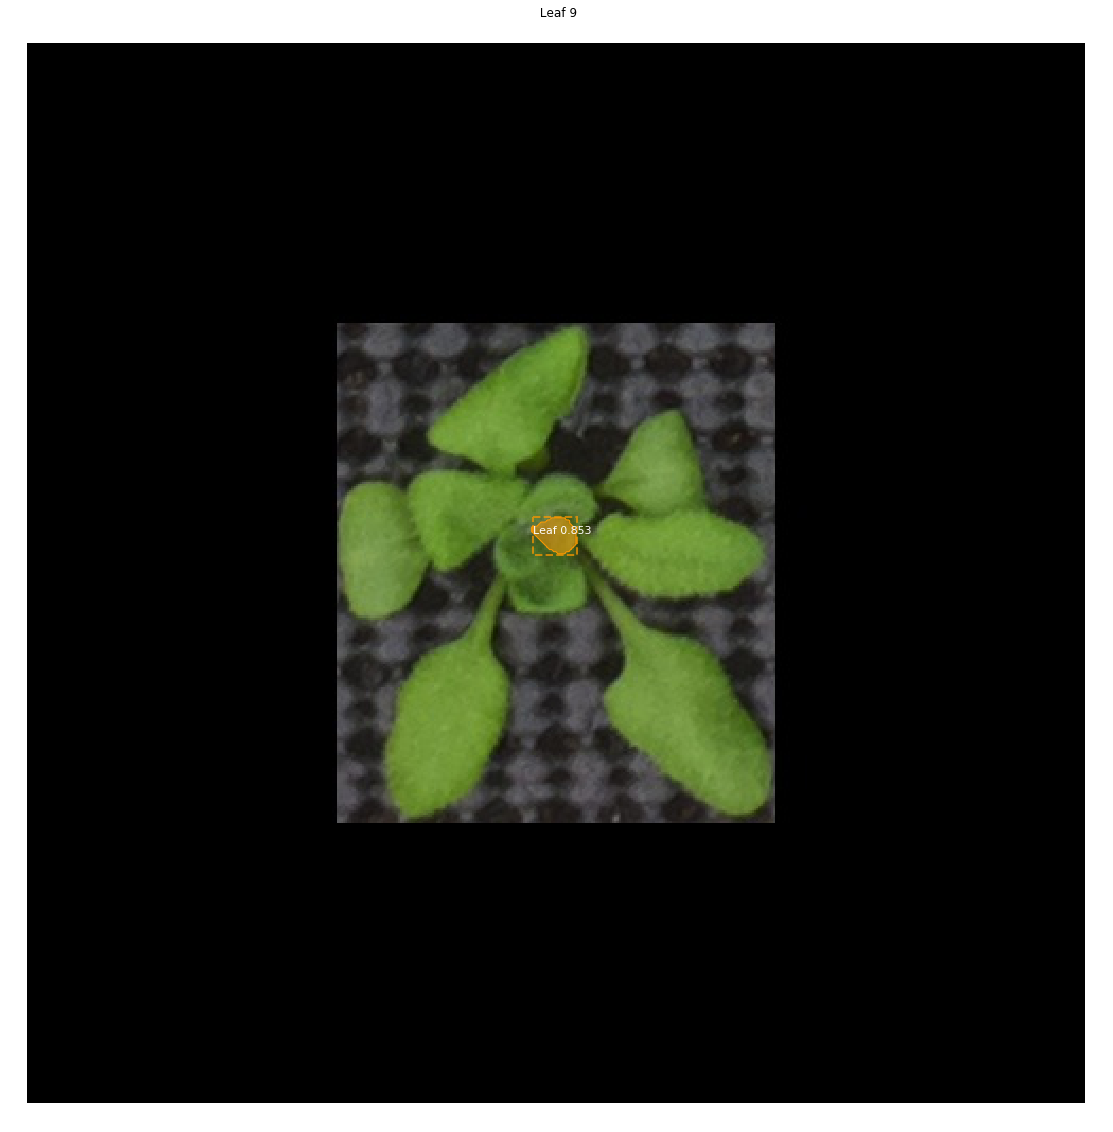

In [ ]:
## show one randomly selected image as an example
instance_seg.inferencing_random_sample()

There is an automated "segmentation quality control" built into the model. For every image, after the initial segmentation, it will check the overlaps of each pair of segmentation masks to check for the following issues:

Issue 1: two segmentation masks heavily overlap each other
    In this instance, the segmentation mask with higher segmentation score would be kept
Issue 2: one mask (Mask-A) overlaps with two or more other masks (Mask-B, Mask-C, etc.)
    In this case, the heavily overlapping mask (Mask-A in this example) will be removed

The printed output message will indicate the change of segmentation before and after quality control. If you found the number of instances before and after quality control are not the same, the segmentation result was adjusted, and you will see two seperate sets of visualizations depicting the segmentation before and after the correction. 

Once you have established your pathways, suffix, and time patterns, you can run the segmentation function in a loop over all files in the defined input directory. Image results will be deposited into the previously set output directory, in addition to a "segmentation_summary.csv" file in the output directory (instance_seg.save_dir), which summarizes the segmentation by printing out the image names, the issues for every image, the number of segments before and after quality control.

Note: this process might take some time to finish.

In [ ]:
## preforms instance segmentation over all files in a specific folder previously set in "imagedir = "
instance_seg.inferencing_all()

start

...

Processing 1 images
image                    shape: (501, 500, 3)         min:    0.00000  max:  166.00000  uint8
molded_images            shape: (1, 1024, 1024, 3)    min: -123.70000  max:   47.20000  float64
image_metas              shape: (1, 14)               min:    0.00000  max: 1024.00000  float64
anchors                  shape: (1, 261888, 4)        min:   -0.08847  max:    1.02591  float32
1 image done. Which is 1

Processing 1 images
image                    shape: (499, 501, 3)         min:    0.00000  max:  171.00000  uint8
molded_images            shape: (1, 1024, 1024, 3)    min: -123.70000  max:   52.20000  float64
image_metas              shape: (1, 14)               min:    0.00000  max: 1024.00000  float64
anchors                  shape: (1, 261888, 4)        min:   -0.08847  max:    1.02591  float32
2 images done. The last one is 10.9.1.241_pos-165-003-020_2019-10-23-11-05_crop-img17.jpg

Processing 1 images
image                    shape: (499, 499, 3)  

If you would like to check the results inside the folder, you can print out the results saved in the pre-set output directory here:

In [7]:
instance_seg.segmentation_dir

'result/segmentation/2020-09-09-14-04/segmentation'

You can also print out the directory for an updated result:

In [8]:
instance_seg.updated_dir

'result/segmentation/2020-09-09-14-04/segmentation/updated'